# PCA и t-SNE для пар `image - caption_en`

Этот ноутбук загружает эмбеддинги из `data/eval/results/embeddings_clip.npz`, строит PCA- и t-SNE-проекции для пар `image_embeddings` и `predicted_caption_en_embeddings`, сохраняет графики в PNG и формирует вспомогательные таблицы для отчёта.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
PROJECT_ROOT = Path.cwd().parent
out_dir = PROJECT_ROOT / "data" / "eval" / "results"

with open(out_dir / "predictions_detailed.json", "r", encoding="utf-8") as f:
    rows = json.load(f)

emb = np.load(out_dir / "embeddings_clip.npz")
n = len(rows)

print("PROJECT_ROOT =", PROJECT_ROOT)
print("out_dir =", out_dir)
print("n =", n)
print("arrays =", emb.files)

PROJECT_ROOT = /Users/yanakhalitova/workspace/project-seminar/tsu-image-description
out_dir = /Users/yanakhalitova/workspace/project-seminar/tsu-image-description/data/eval/results
n = 20
arrays = ['image_embeddings', 'reference_short_ru_embeddings', 'predicted_caption_ru_embeddings', 'predicted_caption_en_embeddings', 'archive_prediction_embeddings']


In [4]:
df = pd.DataFrame(rows)
df["image_name"] = df["image_path"].apply(lambda x: Path(x).name)
df[["image_name", "caption_en_prediction", "caption_ru_prediction"]].head()

,image_name,caption_en_prediction,caption_ru_prediction
0,postcard_1.jpg,a black and white photo of trees in the woods,черно-белое фото деревьев в лесу
1,postcard_2.jpg,a painting of people in the woods,Картина людей в лесу
2,postcard_3.jpg,a black and white photo of a river,черно-белое фото реки
3,postcard_4.jpg,a child with a violin,ребенка с скрипкой
4,postcard_5.jpg,a man on a reindeer,Человек на олене


In [5]:
image_emb = emb["image_embeddings"]
text_emb = emb["predicted_caption_en_embeddings"]

X = np.concatenate([image_emb, text_emb], axis=0)

plot_rows = []
for i, row in enumerate(rows):
    plot_rows.append({
        "sample_id": i,
        "kind": "image",
        "short_label": f"I{i+1}",
        "label": Path(row["image_path"]).name,
    })

for i, row in enumerate(rows):
    plot_rows.append({
        "sample_id": i,
        "kind": "caption_en",
        "short_label": f"C{i+1}",
        "label": row["caption_en_prediction"],
    })

plot_df = pd.DataFrame(plot_rows)
plot_df.head()

,sample_id,kind,short_label,label
0,0,image,I1,postcard_1.jpg
1,1,image,I2,postcard_2.jpg
2,2,image,I3,postcard_3.jpg
3,3,image,I4,postcard_4.jpg
4,4,image,I5,postcard_5.jpg


## Вспомогательная таблица косинусных сходств

Эта таблица помогает интерпретировать графики PCA и t-SNE.

In [6]:
sim = cosine_similarity(image_emb, text_emb)
diag = np.diag(sim)

best_offdiag = []
for i in range(n):
    row = sim[i].copy()
    row[i] = -np.inf
    best_offdiag.append(row.max())
best_offdiag = np.array(best_offdiag)
margin = diag - best_offdiag
best_idx = sim.argmax(axis=1)

sim_df = pd.DataFrame({
    "sample_id": np.arange(1, n + 1),
    "image_name": [Path(r["image_path"]).name for r in rows],
    "diag_similarity": diag,
    "best_offdiag_similarity": best_offdiag,
    "margin": margin,
    "best_caption_idx": best_idx + 1,
    "is_correct_diagonal": best_idx == np.arange(n),
})

sim_df.sort_values("margin")

,sample_id,image_name,diag_similarity,best_offdiag_similarity,margin,best_caption_idx,is_correct_diagonal
12,13,postcard_13.jpg,0.241598,0.319186,-0.077588,11,False
9,10,postcard_10.jpg,0.220871,0.277427,-0.056555,12,False
15,16,postcard_16.jpg,0.268378,0.314307,-0.045929,11,False
7,8,postcard_8.jpg,0.289869,0.299136,-0.009267,10,False
6,7,postcard_7.jpg,0.300343,0.306101,-0.005757,10,False
18,19,postcard_19.jpg,0.307608,0.307088,0.000520,19,True
2,3,postcard_3.jpg,0.253839,0.234136,0.019703,3,True
19,20,postcard_20.jpg,0.322517,0.296207,0.026310,20,True
1,2,postcard_2.jpg,0.309889,0.281929,0.027961,2,True
14,15,postcard_15.jpg,0.343228,0.314005,0.029223,15,True


## Функция для отрисовки парных проекций

In [22]:
def plot_pair_projection(df, x_col, y_col, title, save_path=None):
    fig, ax = plt.subplots(figsize=(10, 8))

    markers = {"image": "o", "caption_en": "^"}
    for kind, marker in markers.items():
        mask = df["kind"] == kind
        ax.scatter(
            df.loc[mask, x_col],
            df.loc[mask, y_col],
            marker=marker,
            label=kind,
            alpha=0.8,
        )

    for i in range(n):
        pts = df[df["sample_id"] == i].sort_values(
            by="kind",
            key=lambda s: s.map({"image": 0, "caption_en": 1})
        )
        ax.plot(pts[x_col], pts[y_col], alpha=0.35)

    for _, row in df.iterrows():
        ax.annotate(
            row["short_label"],
            (row[x_col], row[y_col]),
            fontsize=8,
            alpha=0.85,
            xytext=(4, 4),
            textcoords="offset points",
        )

    ax.legend()
    ax.grid(alpha=0.2)

    plt.tight_layout(rect=[0, 0.05, 1, 1])  # оставляем место снизу
    fig.text(0.5, 0.01, title, ha="center", va="bottom", fontsize=12)

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

## PCA

Для малого числа объектов PCA лучше использовать как основной график, поскольку он устойчивее и проще интерпретируется, чем t-SNE.

Explained variance ratio: [0.39149892 0.06706481]


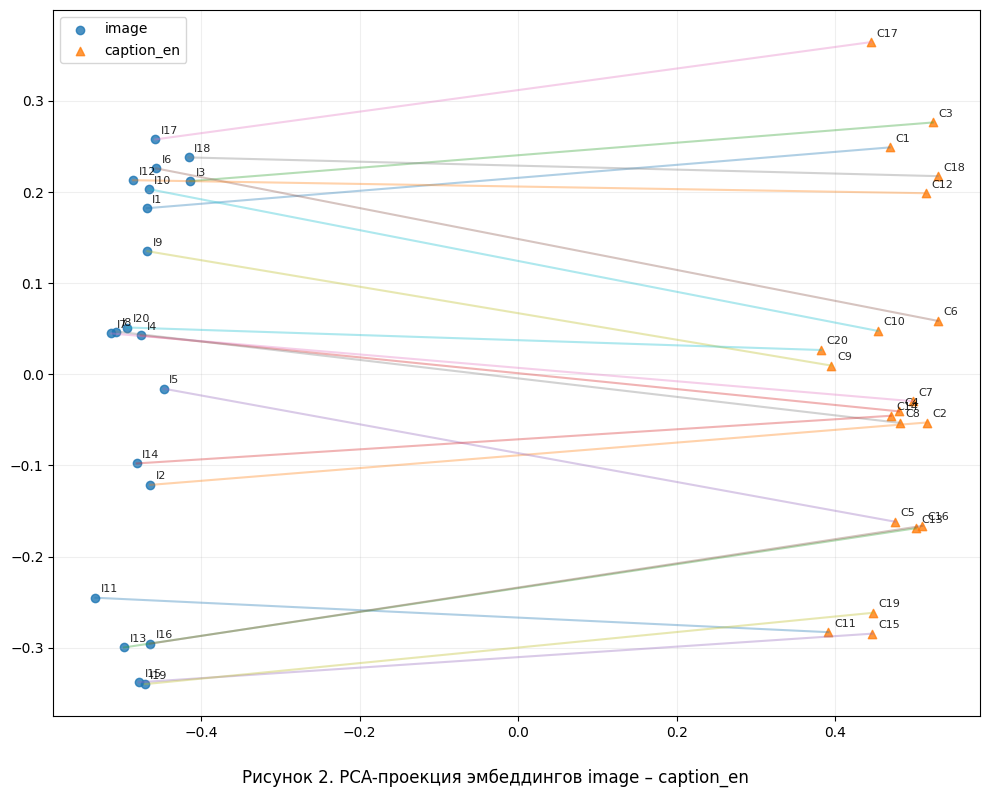

In [24]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

plot_df["pca_x"] = X_pca[:, 0]
plot_df["pca_y"] = X_pca[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)

plot_pair_projection(
    plot_df,
    "pca_x",
    "pca_y",
    "Рисунок 2. PCA-проекция эмбеддингов image – caption_en",
    save_path=out_dir / "figure_pca_image_caption_en.png",
)

## t-SNE

t-SNE стоит рассматривать как дополнительную иллюстрацию локальных отношений. На малой выборке результат зависит от параметров, поэтому он не должен быть единственной основой для выводов.

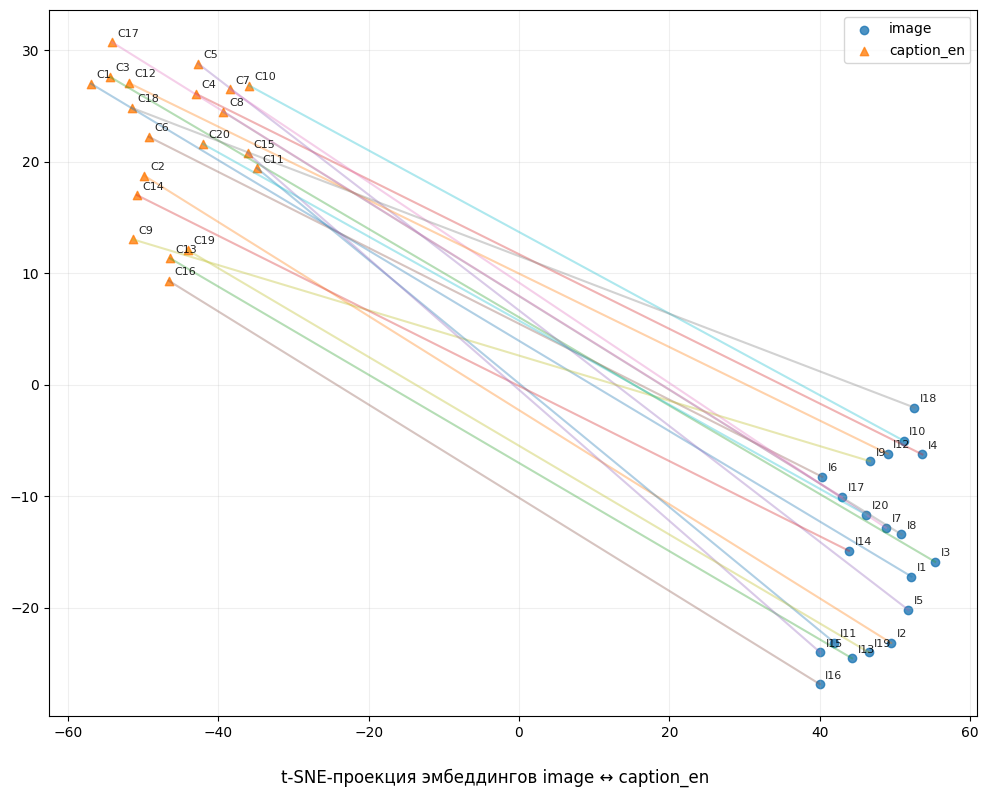

In [25]:
tsne = TSNE(
    n_components=2,
    perplexity=min(5, n - 1),
    init="pca",
    learning_rate="auto",
    random_state=42,
)

X_tsne = tsne.fit_transform(X)
plot_df["tsne_x"] = X_tsne[:, 0]
plot_df["tsne_y"] = X_tsne[:, 1]

plot_pair_projection(
    plot_df,
    "tsne_x",
    "tsne_y",
    "t-SNE-проекция эмбеддингов image ↔ caption_en",
    save_path=out_dir / "figure_tsne_image_caption_en.png",
)

## Матрица cosine similarity

Эта визуализация помогает соотнести выводы PCA/t-SNE с исходными значениями сходства.

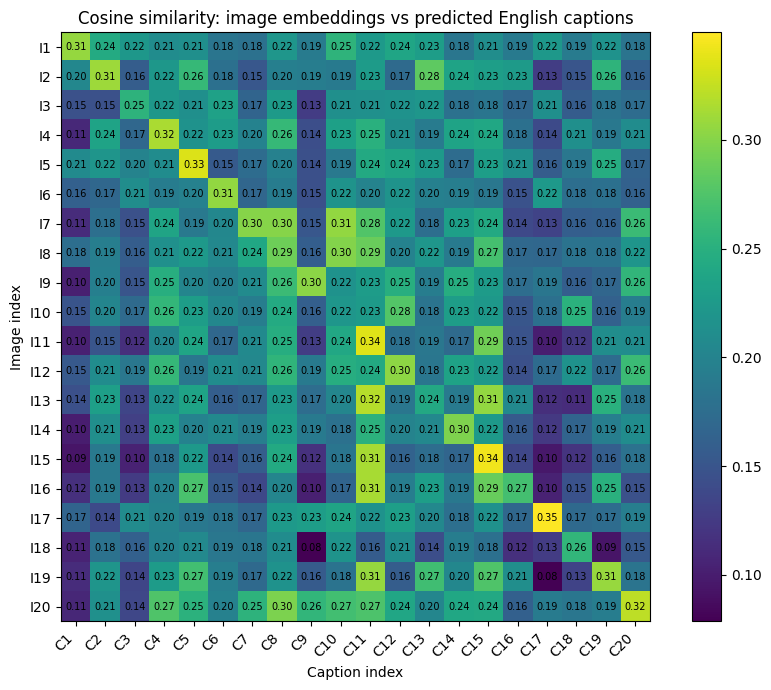

In [11]:
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(sim)

ax.set_title("Cosine similarity: image embeddings vs predicted English captions")
ax.set_xlabel("Caption index")
ax.set_ylabel("Image index")
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels([f"C{i+1}" for i in range(n)], rotation=45, ha="right")
ax.set_yticklabels([f"I{i+1}" for i in range(n)])

for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim[i, j]:.2f}", ha="center", va="center", fontsize=7)

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig(out_dir / "figure_heatmap_image_caption_en.png", dpi=300, bbox_inches="tight")
plt.show()

## Краткая интерпретация для отчёта

Ниже можно автоматически собрать несколько чисел для текстового описания результатов.

In [12]:
summary = {
    "num_examples": n,
    "mean_diag_similarity": float(diag.mean()),
    "mean_best_offdiag_similarity": float(best_offdiag.mean()),
    "mean_margin": float(margin.mean()),
    "top1_accuracy": float((best_idx == np.arange(n)).mean()),
}
summary

{'num_examples': 20,
 'mean_diag_similarity': 0.29830268025398254,
 'mean_best_offdiag_similarity': 0.27297085523605347,
 'mean_margin': 0.025331804528832436,
 'top1_accuracy': 0.75}